In [1]:
import sys
from unlearn_utils import *
from safetensors.torch import save_file, load_file
import torch
import numpy as np
from diffusers import StableDiffusionPipeline
import random
import pandas as pd
from diffusers import DiffusionPipeline
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = torch.device("cuda") 

/home/huiqiangchen/miniconda3/envs/spm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
negative_prompt = "bad anatomy,watermark,extra digit,signature,worst quality,jpeg artifacts,normal quality,low quality,long neck,lowres,error,blurry,missing fingers,fewer digits,missing arms,text,cropped,Humpbacked ,bad hands,username"
MODEL_NAME="CompVis/stable-diffusion-v1-4"

In [4]:
pipe_hooker = PipeWithHooker.from_pretrained(MODEL_NAME,
                                             torch_dtype=torch.float16).to(device)
layer_id=0
embed_encoder_txt =get_embedding(pipe_hooker, 
								'./prompt_template3.txt', 
								concept='claude monet', 
								postion = 'unet',
								layer_id=layer_id)
del pipe_hooker

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


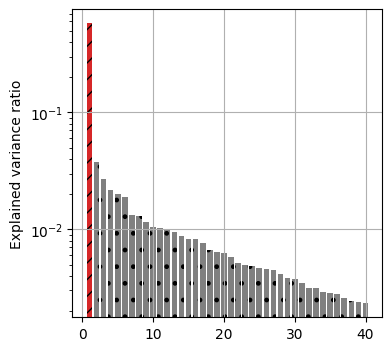

In [5]:
proj_monet_text, S=get_proj(embed_encoder_txt, rank=1, lam=1, plot=True)
plot_exp_var(S)

In [6]:
proj_pipe_text = StableDiffusionPipeline.from_pretrained(
	MODEL_NAME,
	torch_dtype=torch.float16,
	safety_checker = None).to(device)
project_attn_layers(proj_pipe_text, proj_monet_text)
# project_text_conder_attn

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


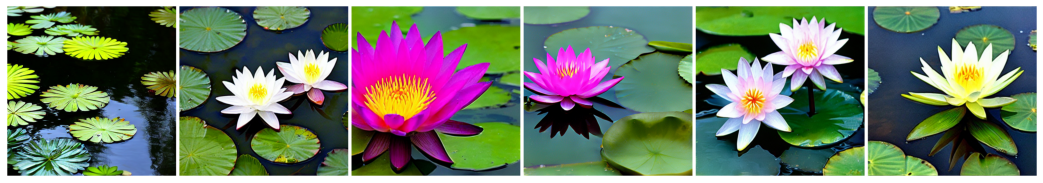

save pdf temp_folder/a8987efa-a88d-11ef-aceb-b0a460e9ad36.png, raw data at temp_folder/a8987efa-a88d-11ef-aceb-b0a460e9ad36.pth


In [15]:
prompt="A paint of water lily by French painter Claude Monet"
num_img=6
seed=2025
image = generate_img(proj_pipe_text, 
					prompt, 
					num_img=num_img, 
					negative_prompt=negative_prompt,
					seed=seed,
					)
showimages(image)

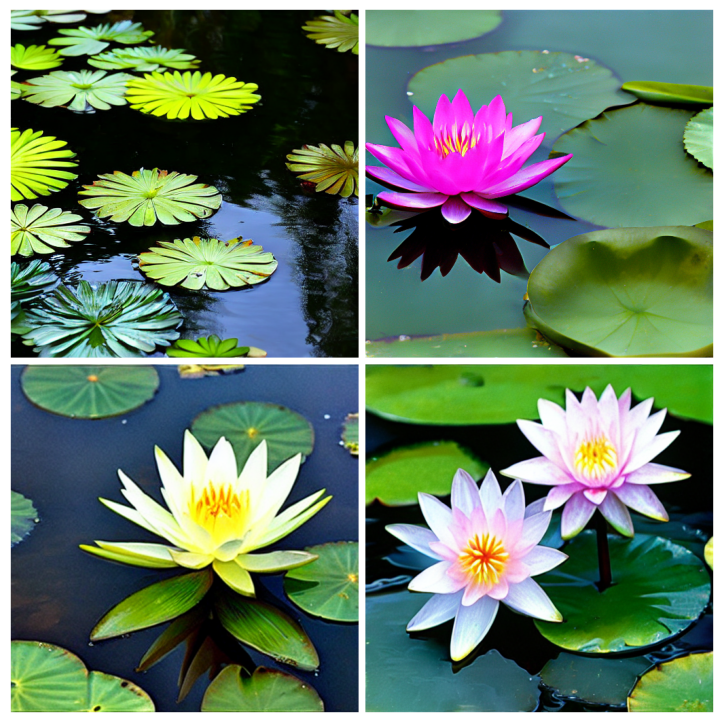

save pdf temp_folder/b09bc850-a88d-11ef-aceb-b0a460e9ad36.png, raw data at temp_folder/b09bc850-a88d-11ef-aceb-b0a460e9ad36.pth


In [16]:
raw_water_lily = torch.load('./temp_folder/a8987efa-a88d-11ef-aceb-b0a460e9ad36.pth')
showimages([raw_water_lily[0], raw_water_lily[3], raw_water_lily[5], raw_water_lily[4]], max_per_row=2)

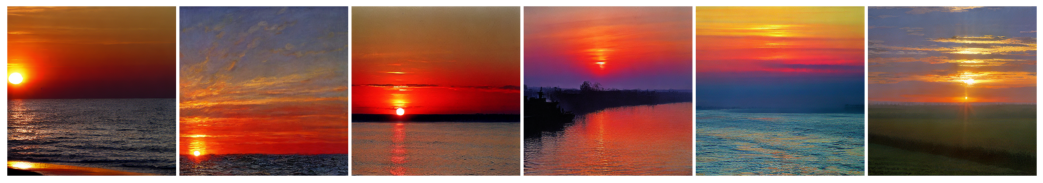

save pdf temp_folder/8c62f5b0-a88a-11ef-aceb-b0a460e9ad36.png, raw data at temp_folder/8c62f5b0-a88a-11ef-aceb-b0a460e9ad36.pth


In [9]:
prompt="A paint of sunrise by French Impressionism painter Claude Monet"
num_img=6
seed=2025
image = generate_img(proj_pipe_text, 
					prompt, 
					num_img=num_img, 
					negative_prompt=negative_prompt,
					seed=seed,
					)
showimages(image)

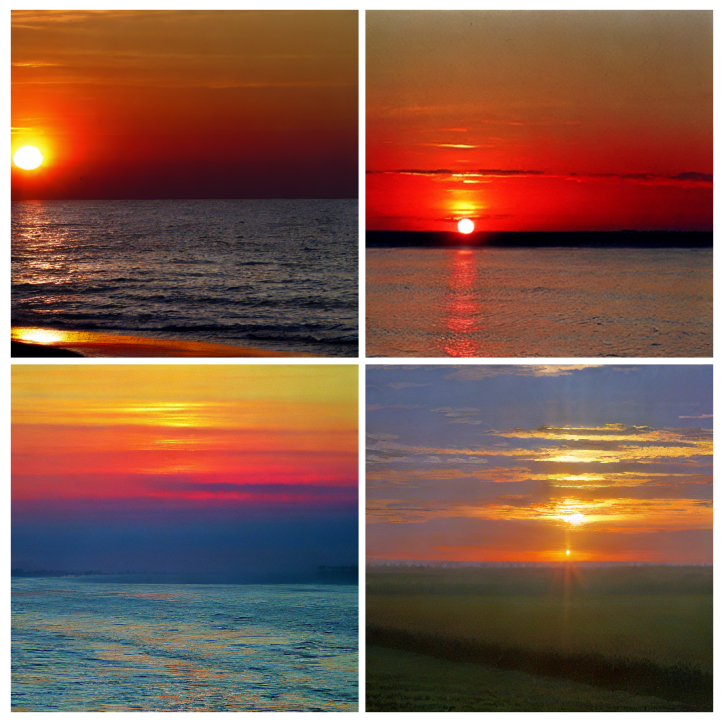

save pdf temp_folder/0abe0aee-a88b-11ef-aceb-b0a460e9ad36.png, raw data at temp_folder/0abe0aee-a88b-11ef-aceb-b0a460e9ad36.pth


In [14]:
raw_sunrise = torch.load('./temp_folder/8c62f5b0-a88a-11ef-aceb-b0a460e9ad36.pth')
showimages([raw_sunrise[0], raw_sunrise[2], raw_sunrise[4], raw_sunrise[5]], max_per_row=2)